# Missing Metadata Bar Chart

Purpose: Create bar chart that shows how much data has metadata (collection date, state) missing from SRA (Andersen Lab)

Three categories:
* Collection date and state
* No collection date, yes state
* Missing metadata

In [1]:
# Housekeeping

import os
import glob 
import pandas as pd
import xml.etree.ElementTree as ET
import requests
import time
import numpy as np
import dateutil 
from datetime import datetime
from collections import defaultdict 
import matplotlib.pyplot as plt

In [2]:
# Make sure you have the correct paths

# home = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/"
home = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu"
# downloads = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/"
downloads = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/"
originals = downloads + "Andersen/"
temp_files = originals + "temp/"
complete_files = originals + "complete/"

# Day we're updating data
update_date = "05-20-2025"

os.chdir(downloads)

In [3]:
# Read metadata

metadata_folder = originals + "avian-influenza/metadata/"
os.chdir(metadata_folder)

metadata = pd.read_csv("SraRunTable_automated.csv")
metadata["sample"] = metadata["Run"]

# Looking for B3.13 only

# Get genotype from genoflu_results.tsv

genoflu_results = pd.read_csv("genoflu_results.tsv", delimiter="\t")

metadata = metadata.merge(genoflu_results, on="sample", how="left")
metadata = metadata[metadata["Genotype"] == "B3.13"]

print(metadata)

              Run Assay Type  AvgSpotLen      Bases    BioProject  \
0     SRR28752446        WGS      146.11   93605195  PRJNA1102327   
1     SRR28752447        WGS      241.29   86080323  PRJNA1102327   
2     SRR28752448        WGS      250.30   75035343  PRJNA1102327   
3     SRR28752449        WGS      146.61   59363690  PRJNA1102327   
4     SRR28752450        WGS      251.31  119232569  PRJNA1102327   
...           ...        ...         ...        ...           ...   
8951  SRR33369828        WGS      147.77  151231202  PRJNA1102327   
8952  SRR33369829        WGS      147.72  146740267  PRJNA1102327   
8953  SRR33369830        WGS      148.50  182024260  PRJNA1102327   
8954  SRR33369831        WGS      148.39  131993112  PRJNA1102327   
8955  SRR33369832        WGS      146.48  232073985  PRJNA1102327   

         BioSample BioSampleModel     Bytes Center Name Collection_Date  ...  \
0     SAMN41019184          Viral  30074178   USDA-NVSL            2024  ...   
1     SAMN4

In [4]:
# Get specific geolocation from genbank_mapping.tsv

genbank_mapping = pd.read_csv("genbank_mapping.tsv", delimiter="\t")
genbank_mapping["Run"] = genbank_mapping["sra_run"]
genbank_mapping = genbank_mapping.drop_duplicates(subset="Run", keep="first") # Drop duplicates
genbank_mapping["name_state"] = genbank_mapping["genbank_name"].apply(lambda x: x.split("/")[2]) # Get the name of the state

print(genbank_mapping)

metadata_genbank = metadata.merge(genbank_mapping, on=["Run"], how="left") # Include data without states

print(genbank_mapping["name_state"])
print(len(metadata_genbank))
display(metadata_genbank) # Maybe there is no state information since 3/18/2025?

                    seg_file  \
0      SRR28752446_HA_cns.fa   
8      SRR28752447_HA_cns.fa   
16     SRR28752448_HA_cns.fa   
24     SRR28752449_HA_cns.fa   
32     SRR28752450_HA_cns.fa   
...                      ...   
40738  SRR33124773_HA_cns.fa   
40746  SRR33124774_HA_cns.fa   
40754  SRR33124775_HA_cns.fa   
40762  SRR33124776_HA_cns.fa   
40770  SRR33124777_HA_cns.fa   

                                            seg_seq_name      sra_run seg  \
0      Consensus_SRR28752446_HA_cns_threshold_0.5_qua...  SRR28752446  HA   
8      Consensus_SRR28752447_HA_cns_threshold_0.5_qua...  SRR28752447  HA   
16     Consensus_SRR28752448_HA_cns_threshold_0.5_qua...  SRR28752448  HA   
24     Consensus_SRR28752449_HA_cns_threshold_0.5_qua...  SRR28752449  HA   
32     Consensus_SRR28752450_HA_cns_threshold_0.5_qua...  SRR28752450  HA   
...                                                  ...          ...  ..   
40738  Consensus_SRR33124773_HA_cns_threshold_0.5_qua...  SRR33124773  HA   

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Collection_Date,...,Genotype Mismatch List,Genotype Average Depth of Coverage List,seg_file,seg_seq_name,sra_run,seg,genbank_acc,genbank_seg,genbank_name,name_state
0,SRR28752446,WGS,146.11,93605195,PRJNA1102327,SAMN41019184,Viral,30074178,USDA-NVSL,2024,...,"25, 11, 18, 21, 10, 13, 11, 7",Ran on FASTA - No Coverage Report,SRR28752446_HA_cns.fa,Consensus_SRR28752446_HA_cns_threshold_0.5_qua...,SRR28752446,HA,PP740722.1,4.0,A/blackbird/Texas/24-008354-001/2024,Texas
1,SRR28752447,WGS,241.29,86080323,PRJNA1102327,SAMN41019237,Viral,28164109,USDA-NVSL,2024,...,"26, 10, 18, 21, 9, 13, 11, 6",Ran on FASTA - No Coverage Report,SRR28752447_HA_cns.fa,Consensus_SRR28752447_HA_cns_threshold_0.5_qua...,SRR28752447,HA,PP752829.1,4.0,A/cattle/Texas/24-009108-005/2024,Texas
2,SRR28752448,WGS,250.30,75035343,PRJNA1102327,SAMN41019236,Viral,24547283,USDA-NVSL,2024,...,"26, 10, 17, 21, 10, 13, 11, 7",Ran on FASTA - No Coverage Report,SRR28752448_HA_cns.fa,Consensus_SRR28752448_HA_cns_threshold_0.5_qua...,SRR28752448,HA,PP752821.1,4.0,A/cattle/Texas/24-009108-004/2024,Texas
3,SRR28752449,WGS,146.61,59363690,PRJNA1102327,SAMN41019235,Viral,19686302,USDA-NVSL,2024,...,"26, 10, 18, 21, 9, 13, 11, 6",Ran on FASTA - No Coverage Report,SRR28752449_HA_cns.fa,Consensus_SRR28752449_HA_cns_threshold_0.5_qua...,SRR28752449,HA,PP752813.1,4.0,A/cattle/Texas/24-009108-003/2024,Texas
4,SRR28752450,WGS,251.31,119232569,PRJNA1102327,SAMN41019234,Viral,38846827,USDA-NVSL,2024,...,"27, 10, 17, 21, 10, 13, 11, 7",Ran on FASTA - No Coverage Report,SRR28752450_HA_cns.fa,Consensus_SRR28752450_HA_cns_threshold_0.5_qua...,SRR28752450,HA,PP752805.1,4.0,A/cattle/Texas/24-009108-002/2024,Texas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4324,SRR33369828,WGS,147.77,151231202,PRJNA1102327,SAMN48199901,Viral,61906964,USDA-NVSL,2025,...,"27, 25, 16, 12, 39, 10, 15, 18",Ran on FASTA - No Coverage Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4325,SRR33369829,WGS,147.72,146740267,PRJNA1102327,SAMN48199900,Viral,59125311,USDA-NVSL,2025,...,"10, 15, 18, 16, 39, 27, 25, 12",Ran on FASTA - No Coverage Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4326,SRR33369830,WGS,148.50,182024260,PRJNA1102327,SAMN48199899,Viral,74408243,USDA-NVSL,2024,...,"10, 16, 31, 14, 8, 11, 25, 19",Ran on FASTA - No Coverage Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4327,SRR33369831,WGS,148.39,131993112,PRJNA1102327,SAMN48199890,Viral,54162419,USDA-NVSL,2024,...,"10, 10, 21, 17, 30, 11, 24, 15",Ran on FASTA - No Coverage Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
def search_collection_date(biosample, metadata_genbank):

    print(biosample)

    try:
    
        base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
        search_url = base_url + "esearch.fcgi?db=biosample&term=" + biosample +"&usehistory=y&api_key=2cbaf77ac9ec5ae7844ea350076ae6d56809"

        # Get Biosample ID from search_url
        output = requests.get(search_url)
        xml = output.content
        root = ET.fromstring(xml)
        sample_id = root.find("./IdList/Id").text

        biosample_url = base_url + "elink.fcgi?dbfrom=biosample&db=nuccore&id=" + sample_id + "&cmd=neighbor_history&api_key=2cbaf77ac9ec5ae7844ea350076ae6d56809"
        
        # Get Nucleotide ID from biosample_url
        output = requests.get(biosample_url)
        xml = output.content
        root = ET.fromstring(xml)
        query_key = root.find(".//QueryKey").text
        web_env = root.find(".//WebEnv").text

        nucleotide_url = base_url + "esummary.fcgi?db=nuccore&query_key=" + query_key + "&WebEnv=" + web_env + "&version=2.0&api_key=2cbaf77ac9ec5ae7844ea350076ae6d56809"

        print(nucleotide_url)

        output = requests.get(nucleotide_url) 
        xml = output.content
        root = ET.fromstring(xml)

        # Grab collection date at the end of the sub name
        collection_date = root.find(".//SubName").text.split("|")[-1]

        # Grab geo_location as well
        geo_location = root.find(".//SubName").text.split("/")[2]

        # If there's a state associated, re-format
        geo_location = geo_location.replace(": ", "-")

        print(collection_date)

        # Avoid spamming the server
        time.sleep(2)

        return geo_location + "|" + collection_date
    
    except:
        print("Unable to find collection date.")

        if len(metadata_genbank[metadata_genbank["BioSample"] == biosample]["Collection_Date"]) > 0: # If a year exists
            collection_date = metadata_genbank[metadata_genbank["BioSample"] == biosample]["Collection_Date"].values[0]
        else:
            collection_date = float('nan') 

        # Avoid spamming the server
        time.sleep(1)

        return collection_date

In [6]:
# metadata_genbank["Collection_Date_Specific"] = metadata_genbank["BioSample"].apply(lambda x: search_collection_date(x, metadata_genbank))

# # Save this so we don't have to do it again

# os.chdir(temp_files)
# metadata_genbank.to_csv("metadata_genbank_" + update_date + ".csv")

In [7]:
# Comment the above cell out if using this cell

os.chdir(originals + "saved/")
metadata_genbank_collection_dates = pd.read_csv("metadata_genbank_" + update_date + "_B3_13.csv")
metadata_genbank_collection_dates["sample"] = metadata_genbank_collection_dates["Run"]
metadata_genbank_dates_small = metadata_genbank_collection_dates[["sample", "Collection_Date_Specific"]]

metadata_genbank = metadata_genbank.merge(metadata_genbank_dates_small, on="sample", how="right")

print(metadata_genbank)

metadata_genbank["Collection_Date_State"] = metadata_genbank["Collection_Date_Specific"].apply(lambda x: True if pd.notna(x) and x.split("|")[-1] != x.split("|")[0] else False)
metadata_genbank["No_Collection_Date"] = metadata_genbank["Collection_Date_Specific"].apply(lambda x: False if pd.notna(x) and x.split("|")[0] != x.split("|")[-1] else True)
metadata_genbank["Neither"] = metadata_genbank["Collection_Date_Specific"].apply(lambda x: True if pd.isna(x) else False)
# "Neither" category is denoted by nan in collection_date_specific

# Get months
metadata_genbank["Month_Year"] = metadata_genbank["ReleaseDate"].apply(lambda x: x.split("|")[-1].split("-")[0] + "-" + x.split("|")[-1].split("-")[1] if pd.notna(x) else x)

print(metadata_genbank["Collection_Date_Specific"].apply(pd.isna).sum()) # 33 "neither"'s

print(metadata_genbank)

              Run Assay Type  AvgSpotLen        Bases    BioProject  \
0     SRR28752448        WGS      250.30   75035343.0  PRJNA1102327   
1     SRR28752449        WGS      146.61   59363690.0  PRJNA1102327   
2     SRR28752450        WGS      251.31  119232569.0  PRJNA1102327   
3     SRR28752453        WGS      144.71   37055919.0  PRJNA1102327   
4     SRR28752455        WGS      147.62   63694864.0  PRJNA1102327   
...           ...        ...         ...          ...           ...   
4324          NaN        NaN         NaN          NaN           NaN   
4325          NaN        NaN         NaN          NaN           NaN   
4326          NaN        NaN         NaN          NaN           NaN   
4327          NaN        NaN         NaN          NaN           NaN   
4328          NaN        NaN         NaN          NaN           NaN   

         BioSample BioSampleModel       Bytes Center Name Collection_Date  \
0     SAMN41019236          Viral  24547283.0   USDA-NVSL            2

   Month_Year  Collection_Date_State  No_Collection_Date  Neither
0     2024-04                    117                   3        0
1     2024-05                     92                  40       33
2     2024-06                    158                   5        0
3     2024-07                    142                  13        0
4     2024-08                     84                  41        0
5     2024-09                     56                  12        0
6     2024-10                     69                   6        0
7     2024-11                    127                  29        0
8     2024-12                    390                 205        0
9     2025-01                    144                  97        0
10    2025-02                     61                  46        0
11    2025-03                     32                  36        0
12    2025-04                     51                  43        0


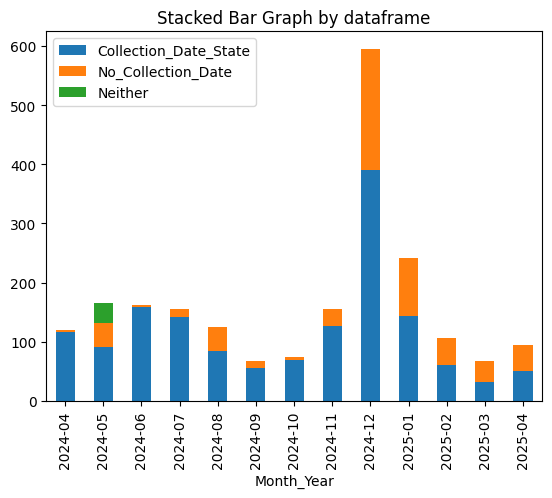

In [10]:
plot_df = metadata_genbank[["Collection_Date_State", "No_Collection_Date", "Neither", "Month_Year"]]

plot_df = plot_df.groupby("Month_Year").sum()
# plot_df["Month_Year"] = plot_df.index
plot_df = plot_df.reset_index()

print(plot_df)

plot_df.plot(x="Month_Year", kind='bar', stacked=True,
        title='Stacked Bar Graph by dataframe')
plt.show()

# print(metadata_genbank["ReleaseDate"]) # release date by month is x-axis 
# y-axis: number of sequences released in that month
# categories: state and collection date, state no collection date, neither 

# print(metadata_genbank)

In [9]:
print(metadata_genbank[metadata_genbank["Month_Year"] == "2023-06"])

Empty DataFrame
Columns: [Run, Assay Type, AvgSpotLen, Bases, BioProject, BioSample, BioSampleModel, Bytes, Center Name, Collection_Date, Consent, DATASTORE filetype, DATASTORE provider, DATASTORE region, Experiment, geo_loc_name_country, geo_loc_name_country_continent, geo_loc_name, Host, Instrument, isolate, Library Name, LibraryLayout, LibrarySelection, LibrarySource, Organism, Platform, ReleaseDate, create_date, version, Sample Name, SRA Study, serotype, isolation_source, BioSample Accession, is_retracted, retraction_detection_date_utc, sample, date, File Name, Genotype, Genotype List Used, >=98.0%, Genotype Sample Title List, Genotype Percent Match List, Genotype Mismatch List, Genotype Average Depth of Coverage List, seg_file, seg_seq_name, sra_run, seg, genbank_acc, genbank_seg, genbank_name, name_state, Collection_Date_Specific, Collection_Date_State, No_Collection_Date, Neither, Month_Year]
Index: []

[0 rows x 59 columns]
